## Dataset Understanding
## Djihane Mahraz 60300310
#### Dataset Overview:
The dataset used in this project comprises demographic indicators across Gulf countries over time. Variables include population figures (total, male, female), annual growth rate, population density, fertility rate, median age (both sexes, male, female), life expectancy at birth, and infant mortality rates. The countries represented are Qatar, Oman, Kuwait, Bahrain, Saudi Arabia, and UAE.

#### Relevance and Objective:
The goal is to perform both inferential statistical analysis and time series forecasting to understand demographic patterns and project future population trends. This is applicable to policy-making, healthcare planning, and regional economic forecasting.

#### Data Source:
The dataset is retreived from the US Census Bureau International Databse portal. A filter was applied for years (1995-2024), countries (GCC) and columns (as mentioned above) then the dataset was exported as a csv file.
The file is loaded into a pandas DataFrame, cleaned, and stored as cleaned_project_csv.csv. Irrelevant columns are dropped, object types are converted to numeric, and date columns are standardized.

## Data loading and pre-processing

This section imports the dataset and performs preprocessing:
- Loads the CSV file into a pandas DataFrame
- Checks for null values and data types
- Converts columns to numeric types where needed
- Drops irrelevant columns (country code 'GENC')
- Converts 'Year' to datetime format
- Exports the cleaned dataset to be used in the dashboard

In [23]:
import pandas as pd

df = pd.read_csv("IDB_20-06-2025.csv")

In [24]:
df.head()

,Name,GENC,Year,Population,Male Population,Female Population,Annual Growth Rate,Population Density,"Median Age, Both Sexes","Median Age, Females","Median Age, Males",Total Fertility Rate,"Life Expectancy at Birth, Both Sexes","Life Expectancy at Birth, Males","Life Expectancy at Birth, Females","Infant Mortality Rate, Both Sexes","Infant Mortality Rate, Male","Infant Mortality Rate, Female"
0,Bahrain,BH,1995,"582,068","333,212","248,856",2.48,765.9,25.9,22.8,28.0,3.09,73.2,71.1,75.3,19.7,22.8,16.5
1,Kuwait,KW,1995,"1,664,326","961,411","702,915",5.41,93.4,26.0,22.4,28.1,3.10,73.4,72.0,74.8,11.5,12.5,10.5
2,Oman,OM,1995,"2,138,564","1,239,069","899,495",2.88,6.9,19.7,16.0,23.6,5.43,70.3,68.6,72.1,25.5,26.6,24.4
3,Qatar,QA,1995,"509,712","333,717","175,995",2.98,44,29.0,21.0,31.8,3.57,74.7,73.2,76.2,10.5,10.7,10.3
4,Saudi Arabia,SA,1995,"18,733,152","10,589,875","8,143,277",2.91,8.7,19.8,16.7,22.7,5.01,69.8,68.5,71.2,29.3,31.3,27.2


In [25]:
# check for null values
df.isnull().sum()

Name                                    0
GENC                                    0
Year                                    0
Population                              0
Male Population                         0
Female Population                       0
Annual Growth Rate                      0
Population Density                      0
Median Age, Both Sexes                  0
Median Age, Females                     0
Median Age, Males                       0
Total Fertility Rate                    0
Life Expectancy at Birth, Both Sexes    0
Life Expectancy at Birth, Males         0
Life Expectancy at Birth, Females       0
Infant Mortality Rate, Both Sexes       0
Infant Mortality Rate, Male             0
Infant Mortality Rate, Female           0
dtype: int64

In [26]:
df.dtypes

Name                                     object
GENC                                     object
Year                                      int64
Population                               object
Male Population                          object
Female Population                        object
Annual Growth Rate                      float64
Population Density                       object
Median Age, Both Sexes                  float64
Median Age, Females                     float64
Median Age, Males                       float64
Total Fertility Rate                    float64
Life Expectancy at Birth, Both Sexes    float64
Life Expectancy at Birth, Males         float64
Life Expectancy at Birth, Females       float64
Infant Mortality Rate, Both Sexes       float64
Infant Mortality Rate, Male             float64
Infant Mortality Rate, Female           float64
dtype: object

In [27]:
# convert object types to numeric
cols = ['Population', 'Male Population', 'Female Population', 'Population Density']
for col in cols:
    df[col] = df[col].str.replace(',', '', regex=False).astype(float)

In [28]:
df.dtypes

Name                                     object
GENC                                     object
Year                                      int64
Population                              float64
Male Population                         float64
Female Population                       float64
Annual Growth Rate                      float64
Population Density                      float64
Median Age, Both Sexes                  float64
Median Age, Females                     float64
Median Age, Males                       float64
Total Fertility Rate                    float64
Life Expectancy at Birth, Both Sexes    float64
Life Expectancy at Birth, Males         float64
Life Expectancy at Birth, Females       float64
Infant Mortality Rate, Both Sexes       float64
Infant Mortality Rate, Male             float64
Infant Mortality Rate, Female           float64
dtype: object

In [29]:
# drop genc column (irrelevant) and rename some columns
df.drop('GENC', axis = 1, inplace = True)
df.rename(columns = {'Name': 'Country'}, inplace = True)

df.head()

,Country,Year,Population,Male Population,Female Population,Annual Growth Rate,Population Density,"Median Age, Both Sexes","Median Age, Females","Median Age, Males",Total Fertility Rate,"Life Expectancy at Birth, Both Sexes","Life Expectancy at Birth, Males","Life Expectancy at Birth, Females","Infant Mortality Rate, Both Sexes","Infant Mortality Rate, Male","Infant Mortality Rate, Female"
0,Bahrain,1995,582068.0,333212.0,248856.0,2.48,765.9,25.9,22.8,28.0,3.09,73.2,71.1,75.3,19.7,22.8,16.5
1,Kuwait,1995,1664326.0,961411.0,702915.0,5.41,93.4,26.0,22.4,28.1,3.10,73.4,72.0,74.8,11.5,12.5,10.5
2,Oman,1995,2138564.0,1239069.0,899495.0,2.88,6.9,19.7,16.0,23.6,5.43,70.3,68.6,72.1,25.5,26.6,24.4
3,Qatar,1995,509712.0,333717.0,175995.0,2.98,44.0,29.0,21.0,31.8,3.57,74.7,73.2,76.2,10.5,10.7,10.3
4,Saudi Arabia,1995,18733152.0,10589875.0,8143277.0,2.91,8.7,19.8,16.7,22.7,5.01,69.8,68.5,71.2,29.3,31.3,27.2


In [30]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [347]:
df.to_csv('cleaned_project_csv.csv')

## Infrential Statistics
This section implements inferential statistical methods to uncover patterns and test hypotheses within the data.

### ANOVA
Performs one-way ANOVA test to check if the mean infant mortality rate differs across countries:
- Null hypothesis: There is no difference in the mean infant mortality rate across different countries.
- Alternative hypothesis: There is a difference in the mean infant mortality rate across different countries.
- Assumptions: normality, homogeneity of variance, independence.
- Post hoc analysis is betrformed to check if the between-country differences are statistically significant.

#### Results:
- p < 0.05, reject the null hypothesis
- Concludes that not all group means are equal
- Post-hoc: no difference in mean between Kuwait and Qatar, Kuwait and UAE, Qatar and UAE, Oman and Saudi Arabia

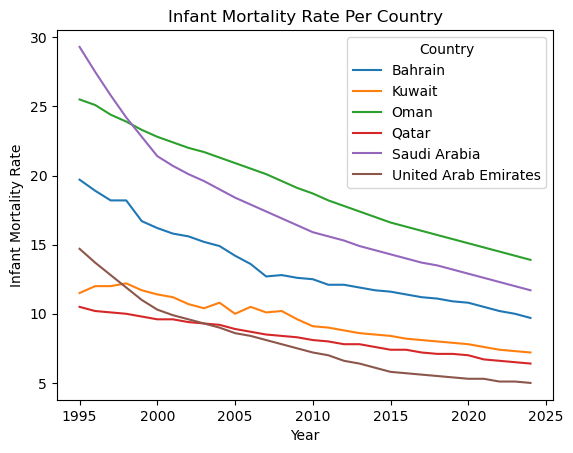

In [52]:
# plot the country infant mortality rates
for country, group in df.groupby('Country'):
    plt.plot(group['Year'], group['Infant Mortality Rate, Both Sexes'], label=country)

plt.title('Infant Mortality Rate Per Country')
plt.xlabel('Year')
plt.ylabel('Infant Mortality Rate')
plt.legend(title='Country', loc='best')
plt.show()

In [50]:
# calculate the means of infant mortality rates for each country
sub = df[['Country', 'Infant Mortality Rate, Both Sexes']]
m2= sub.groupby('Country').mean()
print (m2)

                      Infant Mortality Rate, Both Sexes
Country                                                
Bahrain                                       13.433333
Kuwait                                         9.540000
Oman                                          19.140000
Qatar                                          8.306667
Saudi Arabia                                  17.463333
United Arab Emirates                           7.990000


In [53]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

print("OLS model for the infant mortality rate per country")

# Run ANOVA with country as the group
anova_model = smf.ols('Q("Infant Mortality Rate, Both Sexes") ~ C(Country)', data=df).fit()
print(anova_model.summary())

OLS model for the infant mortality rate per country
                                      OLS Regression Results                                      
Dep. Variable:     Q("Infant Mortality Rate, Both Sexes")   R-squared:                       0.686
Model:                                                OLS   Adj. R-squared:                  0.677
Method:                                     Least Squares   F-statistic:                     76.13
Date:                                    Fri, 20 Jun 2025   Prob (F-statistic):           5.66e-42
Time:                                            13:45:56   Log-Likelihood:                -451.64
No. Observations:                                     180   AIC:                             915.3
Df Residuals:                                         174   BIC:                             934.4
Df Model:                                               5                                         
Covariance Type:                                nonrobust

p_value = 5.66e-42 < 0.05 so we reject the null hypothesis that there is no difference in the mean infant mortality rate for every country. 

Perform post hoc test to check the difference between each sub class

In [54]:
print('Tukey Post Hoc Test')
mc1 = multi.MultiComparison(df['Infant Mortality Rate, Both Sexes'], df['Country'])
res1 = mc1.tukeyhsd()
print(res1.summary())

Tukey Post Hoc Test
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
   group1           group2        meandiff p-adj   lower    upper  reject
-------------------------------------------------------------------------
     Bahrain               Kuwait  -3.8933    0.0  -6.1446  -1.642   True
     Bahrain                 Oman   5.7067    0.0   3.4554   7.958   True
     Bahrain                Qatar  -5.1267    0.0   -7.378 -2.8754   True
     Bahrain         Saudi Arabia     4.03    0.0   1.7787  6.2813   True
     Bahrain United Arab Emirates  -5.4433    0.0  -7.6946  -3.192   True
      Kuwait                 Oman      9.6    0.0   7.3487 11.8513   True
      Kuwait                Qatar  -1.2333 0.6137  -3.4846   1.018  False
      Kuwait         Saudi Arabia   7.9233    0.0    5.672 10.1746   True
      Kuwait United Arab Emirates    -1.55 0.3557  -3.8013  0.7013  False
        Oman                Qatar -10.8333    0.0 -13.0846  -8.582   True
        Oman      

We reject the null hypothesis for all except: between Kuwait and Qatar, Kuwait and the UAE, Oman and Saudi Arabia, Qatar and the UAE.

meaning that there is no significant difference in the infant mortality rate between each of those countries.

### Linear Regression
Applies linear regression to predict median age based on life expectancy:
- Assumptions: linearity, normality, homoscedasticity, independence.
- Visualization includes scatterplot with fitted line and residual analysis.
- The regression coefficients and R² indicate strength and direction of the relationship.

#### Results:
- Scatter plot show the relationship between median age and life expectancy is linear
- Risidual plot shows non linear residuals
- R² = 0.857 demonstrating a good fit of the model
- p < 0.05, reject null hypothesis
- Conclude that there is a relationship between median age and life expectancy
- Obtained formula to calculate the median age

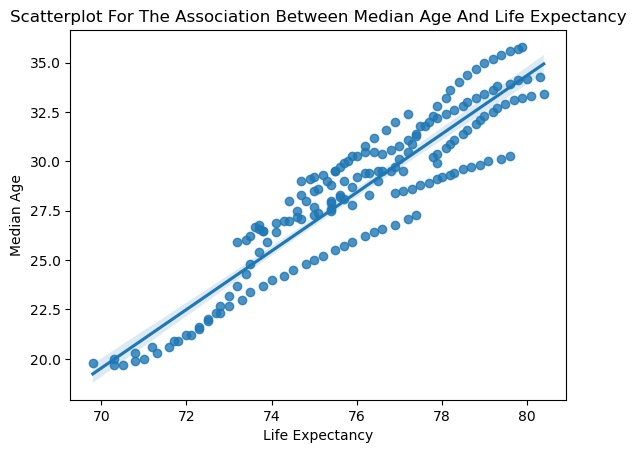

In [57]:
sns.regplot(x="Life Expectancy at Birth, Both Sexes", y="Median Age, Both Sexes", fit_reg=True, data=df)
plt.xlabel('Life Expectancy')
plt.ylabel('Median Age')
plt.title('Scatterplot For The Association Between Median Age And Life Expectancy')
plt.show()

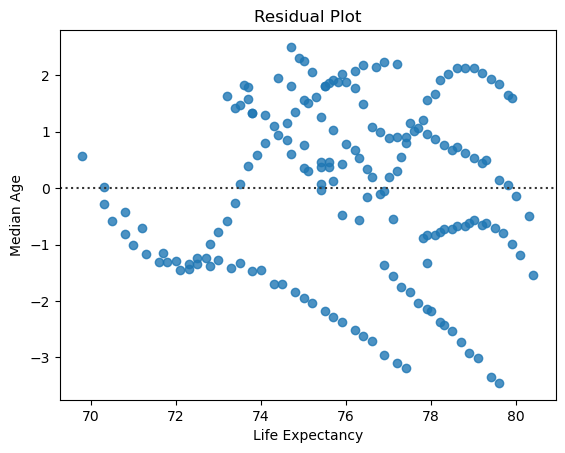

In [58]:
sns.residplot(x="Life Expectancy at Birth, Both Sexes", y="Median Age, Both Sexes",  data=df)
plt.xlabel('Life Expectancy')
plt.ylabel('Median Age')
plt.title('Residual Plot')
plt.show()

In [59]:
print("OLS regression model for the association between median age and life expectancy")
reg = smf.ols('Q("Median Age, Both Sexes") ~ Q("Life Expectancy at Birth, Both Sexes")', data=df).fit()
print(reg.summary())

OLS regression model for the association between median age and life expectancy
                                 OLS Regression Results                                
Dep. Variable:     Q("Median Age, Both Sexes")   R-squared:                       0.857
Model:                                     OLS   Adj. R-squared:                  0.856
Method:                          Least Squares   F-statistic:                     1063.
Date:                         Fri, 20 Jun 2025   Prob (F-statistic):           5.52e-77
Time:                                 13:50:52   Log-Likelihood:                -328.28
No. Observations:                          180   AIC:                             660.6
Df Residuals:                              178   BIC:                             667.0
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                        

The R-square is 0.857 indicating that the model fits the data very well, and that the explanatory variable (life expectancy) has a strong effect on the response variable (median age). This is also indicated by the p value = 5.52e-77 < 0.05, which leads us to reject the null hypothesis that there is no relatinship between the life expectancy and median age.

The formula obtained by the model is: Median age = -84.1435 + 1.4811 * life expectancy at birth 

Example of calculating the expected value:
-

In [78]:
# randomly select a row
random_row = df.sample(n=1)

# get the values and calculate the expected value from the formula
country = random_row['Country'].values[0]
year = random_row['Year'].values[0]
med_age = random_row['Median Age, Both Sexes'].values[0]
life_exp = random_row['Life Expectancy at Birth, Both Sexes'].values[0]

med_age_expected = -84.1435 + (1.4811 * life_exp)

print(f'Country: {country} \nYear: {year} \nActual median age: {med_age} \nExpected median age: {med_age_expected:.1f}')

Country: Qatar 
Year: 2015 
Actual median age: 32.8 
Expected median age: 32.1


### Logistic regression
Builds a logistic regression model to predict whether a country has a high fertility rate:
- Binary target: High_Fertility (1 or 0) created
- Predictor: Country
- Post hoc analysis was performed

#### Results:
- p < 0.05, reject the null hypothesis
- Conclude that the country has an impact on the high firtility rate value
- People from Oman and Saudi Arabia are 17 times more likely to have a high fertility rate

In [79]:
# high fertility > 3
df['High_Fertility'] = (df['Total Fertility Rate'] > 3).astype(int)

In [81]:
df['High_Fertility'].value_counts()

High_Fertility
0    150
1     30
Name: count, dtype: int64

In [105]:
lreg1 = smf.logit(formula = ' High_Fertility ~ Country', data = df).fit()
print (lreg1.summary())

Optimization terminated successfully.
         Current function value: 0.374035
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         High_Fertility   No. Observations:                  180
Model:                          Logit   Df Residuals:                      174
Method:                           MLE   Df Model:                            5
Date:                Fri, 20 Jun 2025   Pseudo R-squ.:                  0.1698
Time:                        17:01:10   Log-Likelihood:                -67.326
converged:                       True   LL-Null:                       -81.101
Covariance Type:            nonrobust   LLR p-value:                 4.457e-05
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -3.3673      1.017     -3.311  

In [106]:
params = lreg1.params
conf = lreg1.conf_int()
conf['OR'] = params
conf.columns = ['Lower CI', 'Upper CI', 'OR']
print (np.exp(conf))

                                 Lower CI    Upper CI         OR
Intercept                        0.004697    0.253137   0.034483
Country[T.Kuwait]                0.177685   24.148456   2.071429
Country[T.Oman]                  2.000646  140.897697  16.789474
Country[T.Qatar]                 0.468208   42.513889   4.461538
Country[T.Saudi Arabia]          2.000646  140.897697  16.789474
Country[T.United Arab Emirates]  0.059654   16.763307   1.000000


The LLR p-value = 4.457e-05 < 0.05 thus we reject the null hypothesis that the country has no impact on the high firtility rate value. The  P>|z| value represents the statistical significance of each country class on the probability of high fertility. Kuwait, Qatar and the UAE all have p values < 0.05 indicating that theyre not statistcallsy significant, wheras Oman and Saudi arabia have p values > 0.05. The odd ratio for Oman and Saudi Arabia = 16.8, meaning that people from Oman and Saudi Arabia are around 17 times more likely to have high firtility rates than other countries. 

### Chi-Sqaured
Performs a chi-square test of independence to assess the relationship between growth rate categories and population density categories:
- Categorical binning applied to both variables.
- Null hypothesis: there is no difference in density between low, medium and high growth rates
- Alternative hypothesis: there is a difference in density between low, medium and high growth rates
- Outputs contingency table, chi-squared statistic, and p-value.
- Performed post hoc analysis with Benferroni adjustment 

#### Results
- p < 0.05, reject the null hypothesis
- Conclude that there is a differnece in density between low, medium and high growth rates
- Theres a difference in density category between low and medium growth rates, and between medium and high growth rates, but no difference between low and high growth rates

In [ ]:
import scipy

In [111]:
# convert annual growth rate and population density into categorical bins
df['Growth_Category'] = pd.qcut(df['Annual Growth Rate'], q=3, labels=['Low', 'Medium', 'High'])
df['Density_Category'] = pd.qcut(df['Population Density'], q=3, labels=['Low', 'Medium', 'High'])

In [112]:
df.head()

,Country,Year,Population,Male Population,Female Population,Annual Growth Rate,Population Density,"Median Age, Both Sexes","Median Age, Females","Median Age, Males",Total Fertility Rate,"Life Expectancy at Birth, Both Sexes","Life Expectancy at Birth, Males","Life Expectancy at Birth, Females","Infant Mortality Rate, Both Sexes","Infant Mortality Rate, Male","Infant Mortality Rate, Female",High_Fertility,Growth_Category,Density_Category
0,Bahrain,1995,582068.0,333212.0,248856.0,2.48,765.9,25.9,22.8,28.0,3.09,73.2,71.1,75.3,19.7,22.8,16.5,1,Medium,High
1,Kuwait,1995,1664326.0,961411.0,702915.0,5.41,93.4,26.0,22.4,28.1,3.10,73.4,72.0,74.8,11.5,12.5,10.5,1,High,Medium
2,Oman,1995,2138564.0,1239069.0,899495.0,2.88,6.9,19.7,16.0,23.6,5.43,70.3,68.6,72.1,25.5,26.6,24.4,1,High,Low
3,Qatar,1995,509712.0,333717.0,175995.0,2.98,44.0,29.0,21.0,31.8,3.57,74.7,73.2,76.2,10.5,10.7,10.3,1,High,Medium
4,Saudi Arabia,1995,18733152.0,10589875.0,8143277.0,2.91,8.7,19.8,16.7,22.7,5.01,69.8,68.5,71.2,29.3,31.3,27.2,1,High,Low


In [115]:
ct1 = pd.crosstab(df['Growth_Category'], df['Density_Category'])
print(ct1)

Density_Category  Low  Medium  High
Growth_Category                    
Low                24      12    24
Medium             29      11    20
High                7      37    16


In [116]:
# column percentages
colsum=ct1.sum(axis=0)
colpct=ct1/colsum
print(colpct)

Density_Category       Low    Medium      High
Growth_Category                               
Low               0.400000  0.200000  0.400000
Medium            0.483333  0.183333  0.333333
High              0.116667  0.616667  0.266667


In [133]:
# print('chi-square value, p value, expected counts')
chi2, p, dof, expected = scipy.stats.chi2_contingency(ct1)
# results
print("Chi-Square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)
print("\nContingency Table:\n", contingency_table)
print("\nExpected Counts:\n", expected)

Chi-Square Statistic: 36.599999999999994
Degrees of Freedom: 4
P-value: 2.17755077363085e-07

Contingency Table:
 Density_Category  Low  Medium  High
Growth_Category                    
Low                24      12    24
Medium             29      11    20
High                7      37    16

Expected Counts:
 [[20. 20. 20.]
 [20. 20. 20.]
 [20. 20. 20.]]


The p value < 0.05 so we reject the null hypothesis that there is no difference in density between low medium and high growth. Perform post hoc analysis to compare for each class, but first calculate the Bonferroni adjustment: 0.05/3 (number of comparisons) = 0.0167, now we compare the p value to 0.0167 instead of 0.05 to check the statistical significance.

In [134]:
sub = df.copy()
cat = ['Low', 'Medium', 'High']

for x in range(0,len(cat)-1):
    for y in range(x+1,len(cat)):
        recode = { cat[x]:cat[x], cat[y]:cat[y]}
        sub['temp'] = sub['Density_Category'].map(recode)
        cont=pd.crosstab(sub['Growth_Category'], sub['temp'])
        cs= scipy.stats.chi2_contingency(cont)
        print("\n", cat[x], " versus ", cat[y],
              "Chi value: ", cs[0], "\t\tp value: ", cs[1])


 Low  versus  Medium Chi value:  32.554545454545455 		p value:  8.528453268901797e-08

 Low  versus  High Chi value:  5.174800354924579 		p value:  0.07521533262929962

 Medium  versus  High Chi value:  14.933657942787583 		p value:  0.000571738424276629


The p value for low versus medium and medium versus high are both less than 0.0167 so we reject the null hypothesis, meaning that there is a significant difference in density catgory between low and medium growth rates, and between medium and high growth rates, but no difference between low and high growth rates

## Time series analysis
This section introduces time series forecasting of population using classical statistical models.

### Pre-processing
Prepares country-wise time series data. Data is grouped and subset by country for modeling purposes.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# make a new dataframe for the time series prediction (total population)

df_ts = df[['Year', 'Country', 'Population']]
df_ts.head()

,Year,Country,Population
0,1995-01-01,Bahrain,582068.0
1,1995-01-01,Kuwait,1664326.0
2,1995-01-01,Oman,2138564.0
3,1995-01-01,Qatar,509712.0
4,1995-01-01,Saudi Arabia,18733152.0


In [33]:
# change year to datetime
df_ts['Year'] = pd.to_datetime(df_ts['Year'], format='%Y')
df_ts.head()

/tmp/ipykernel_488/3750830724.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Year'] = pd.to_datetime(df_ts['Year'], format='%Y')


,Year,Country,Population
0,1995-01-01,Bahrain,582068.0
1,1995-01-01,Kuwait,1664326.0
2,1995-01-01,Oman,2138564.0
3,1995-01-01,Qatar,509712.0
4,1995-01-01,Saudi Arabia,18733152.0


In [34]:
df_ts.dtypes

Year          datetime64[ns]
Country               object
Population           float64
dtype: object

In [35]:
# set year as index
df_ts.set_index('Year', inplace=True)
df_ts.head()

,Country,Population
Year,,
1995-01-01,Bahrain,582068.0
1995-01-01,Kuwait,1664326.0
1995-01-01,Oman,2138564.0
1995-01-01,Qatar,509712.0
1995-01-01,Saudi Arabia,18733152.0


In [149]:
# create new dataframes for each coutry 
countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']
dataframes = {}

for country in countries:
    temp = df_ts[df_ts['Country'] == country]
    dataframes[country] = temp

df_bh = dataframes['Bahrain']
df_kw = dataframes['Kuwait']
df_om = dataframes['Oman']
df_qr = dataframes['Qatar']
df_sa = dataframes['Saudi Arabia']
df_uae = dataframes['United Arab Emirates']

In [150]:
df_qr.head()

,Country,Population
Year,,
1995-01-01,Qatar,509712.0
1996-01-01,Qatar,524831.0
1997-01-01,Qatar,547595.0
1998-01-01,Qatar,578194.0
1999-01-01,Qatar,608950.0


In [151]:
df_qr.describe()

,Population
count,3.000000e+01
mean,1.548306e+06
std,7.748415e+05
min,5.097120e+05
25%,7.114472e+05
50%,1.644328e+06
75%,2.302120e+06
max,2.552088e+06


In [152]:
dataframes = [df_bh, df_kw, df_om, df_qr, df_sa, df_uae]

### Check for stationarity
Applies the Augmented Dickey-Fuller (ADF) test to check for stationarity of the time series. Stationarity is required for ARIMA modeling.

In [215]:
from statsmodels.tsa.stattools import adfuller

for dataframe in dataframes:
    print(dataframe['Country'].values[0])
    adf_result = adfuller(dataframe.drop(columns = ['Country', 'Year'], axis = 1))
    print(f"ADF Statistic: {adf_result[0]}")
    print(f"p-value: {adf_result[1]}\n")

Bahrain
ADF Statistic: -2.854953686411627
p-value: 0.05084263386252631

Kuwait
ADF Statistic: -0.6207520533967745
p-value: 0.8662236312913618

Oman
ADF Statistic: 2.577592723302333
p-value: 0.99907067336433

Qatar
ADF Statistic: -4.903383957044073
p-value: 3.434926990654324e-05

Saudi Arabia
ADF Statistic: 0.10332681082624455
p-value: 0.9662874982462253

United Arab Emirates
ADF Statistic: -1.086624961296508
p-value: 0.7203761370231704



All time series are not stationary except for Qatar which is stationary (p<0.05)

### Visualization
Plots population trends over time to identify trends visually before decomposition.

/tmp/ipykernel_13136/1574779501.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ts['Year'] = df_ts.index


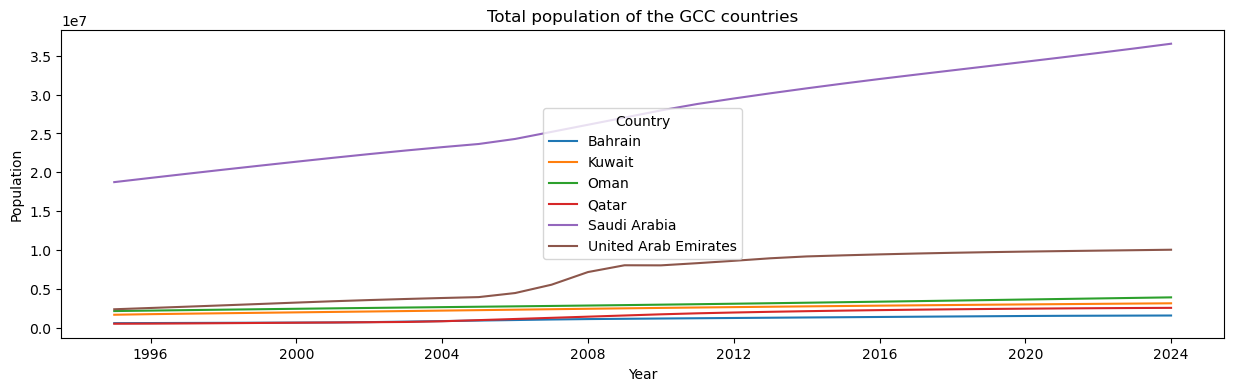

In [162]:
df_ts['Year'] = df_ts.index
plt.figure(figsize=(15, 4))
for country, group in df_ts.groupby('Country'):
    plt.plot(group['Year'], group['Population'], label=country)
plt.title("Total population of the GCC countries")
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend(title='Country', loc='best')
# plt.legend()
plt.show()


### visualize the population of each country
Plots individual country-level population series to compare temporal patterns.

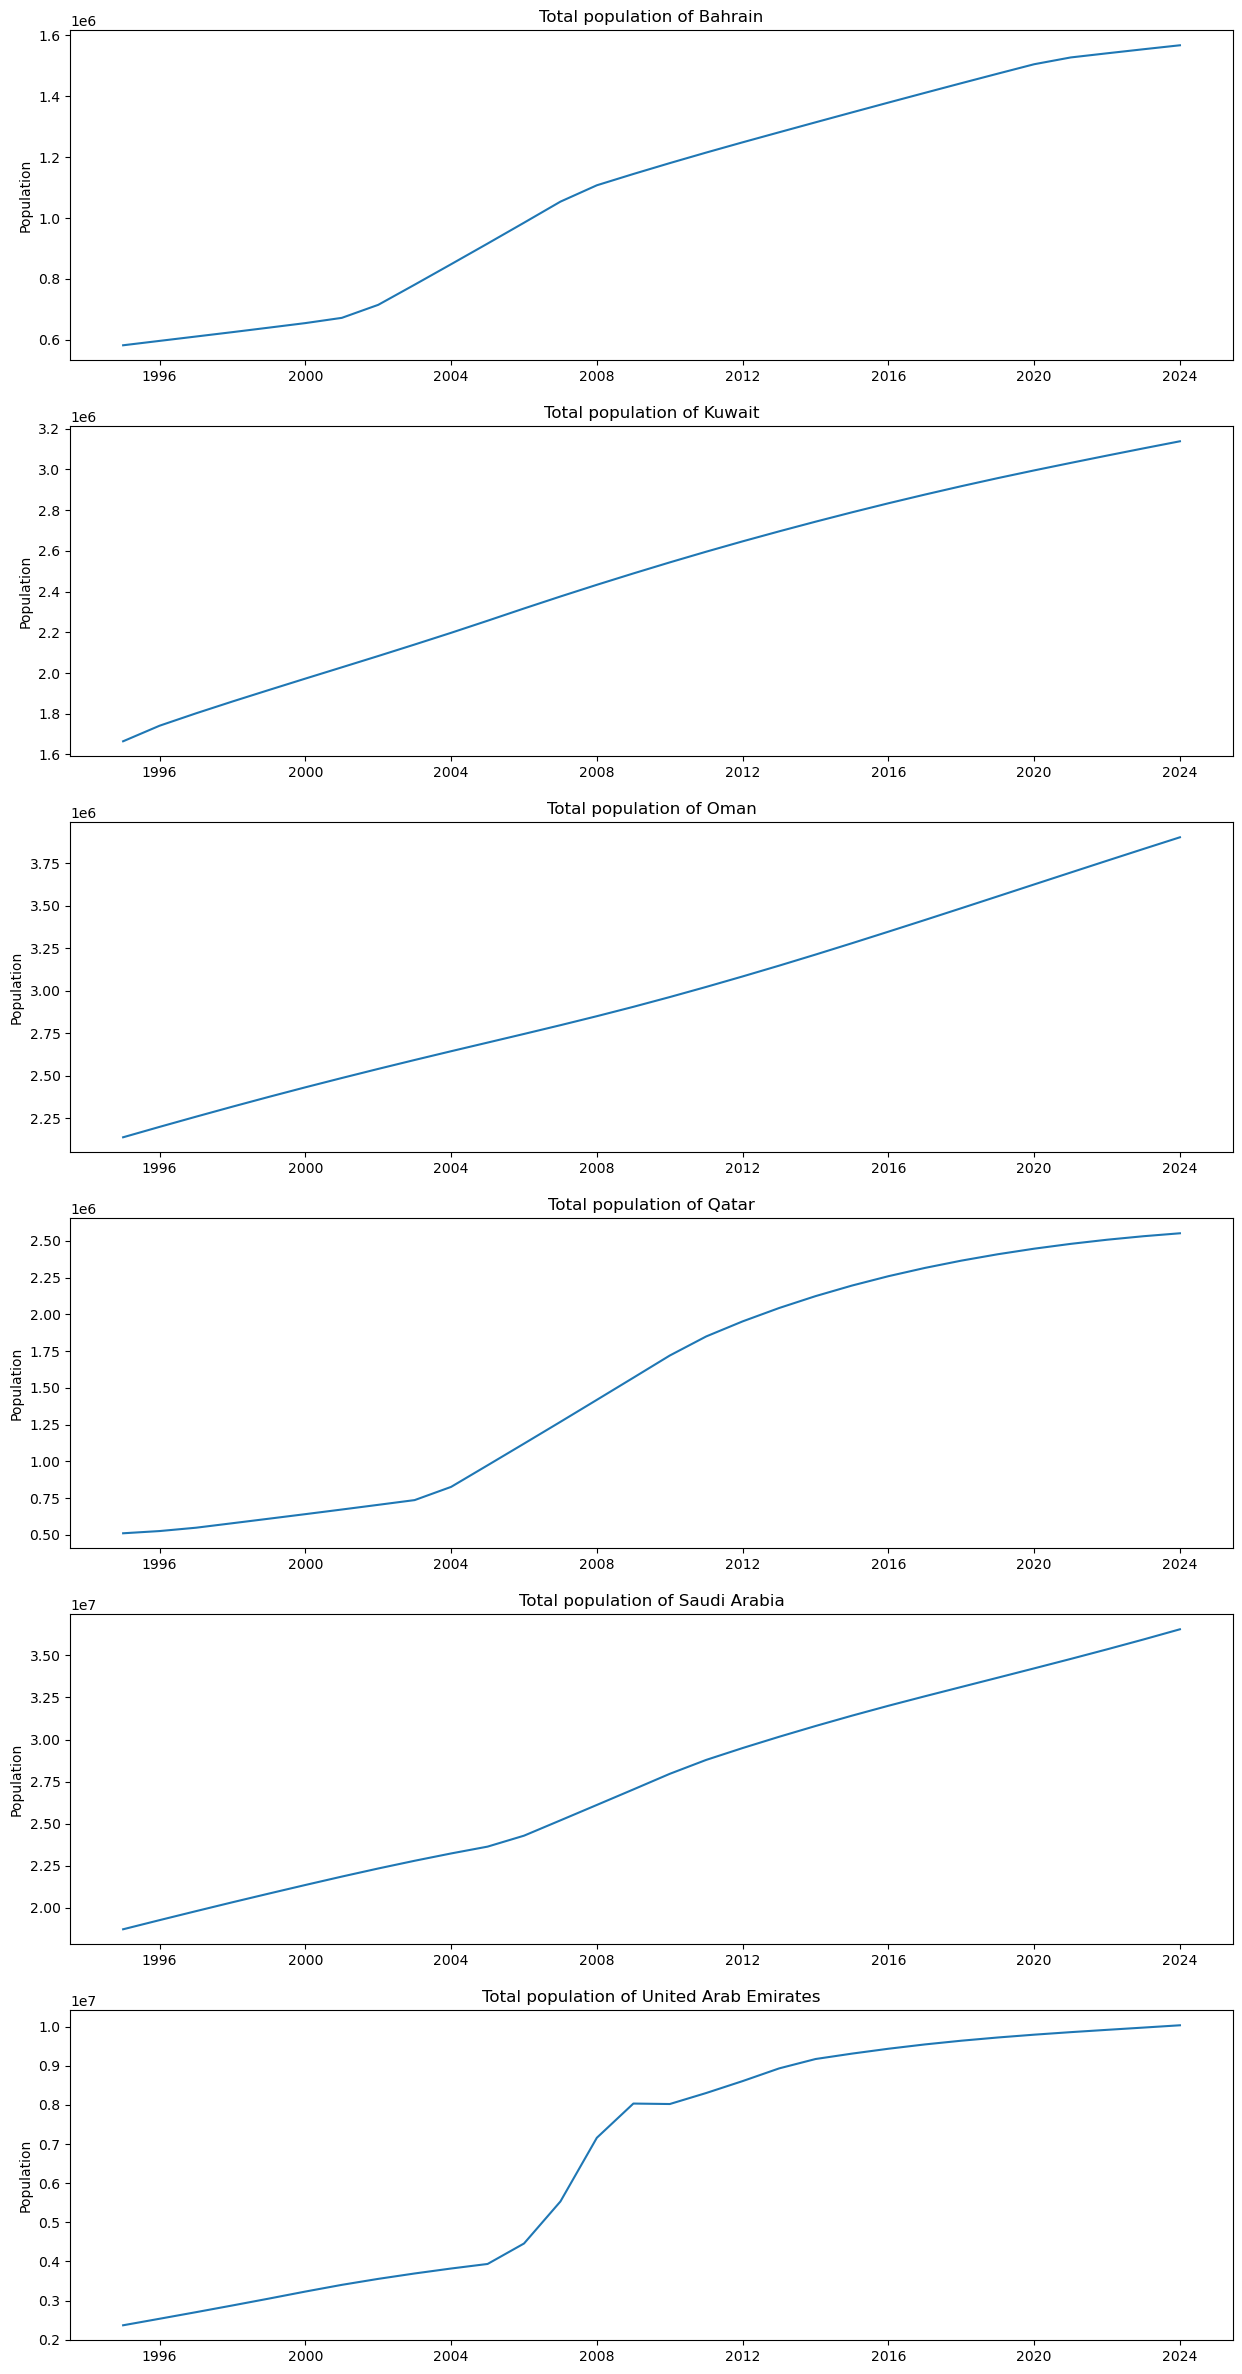

In [184]:
plt.figure(figsize=(15, 30))
for i in range(len(dataframes)):
    plt.subplot(6,1,i+1)
    plt.plot(dataframes[i]['Population'], label='Population')
    plt.title(f"Total population of {dataframes[i]['Country'].values[0]}")
    # plt.xlabel('Year')
    plt.ylabel('Population')
    # plt.legend(loc='best')
plt.show()

### Visualize the seasonal decomposition of each time series
Decomposes each population time series into trend, seasonality, and residual components.

The time series does not grow exponentially so its an additive model, seasonal decompose each one to see the trend, seasonality and risiduals

Bahrain


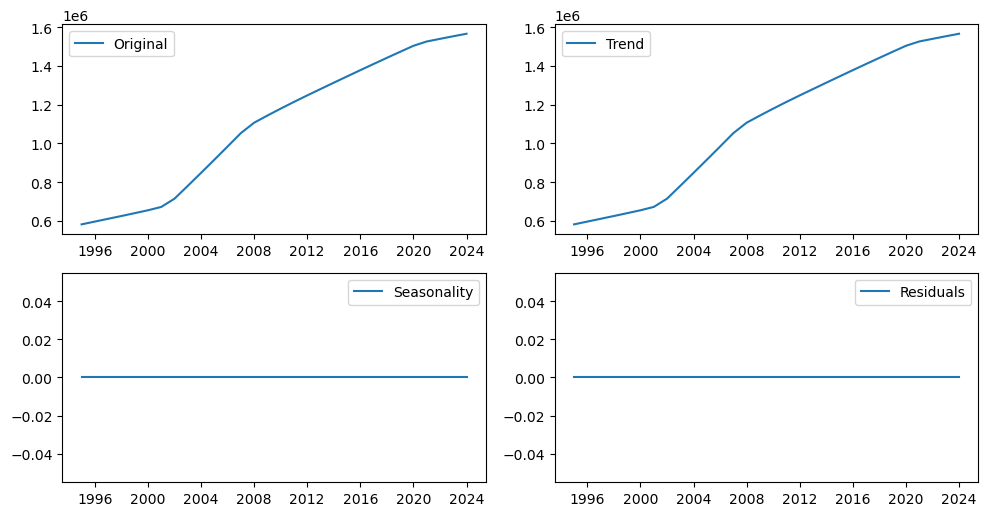



Kuwait


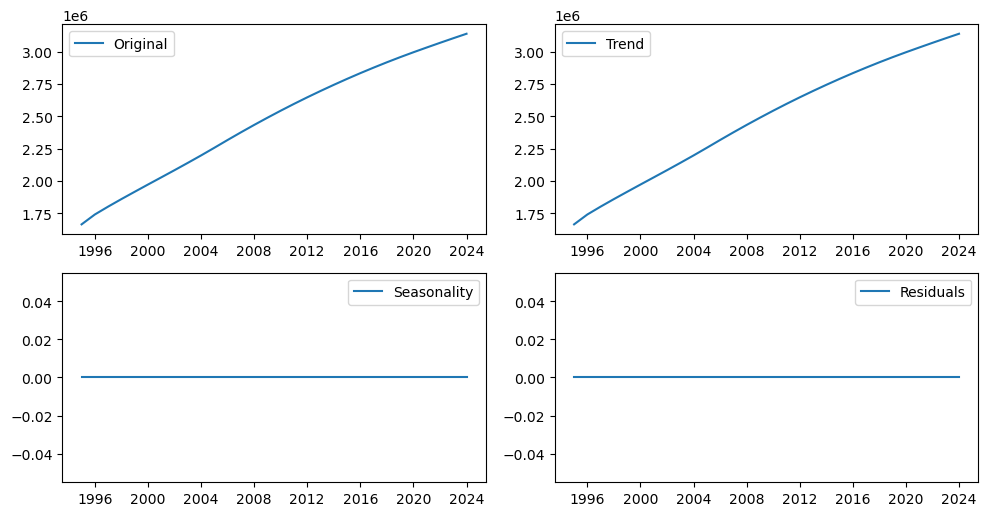



Oman


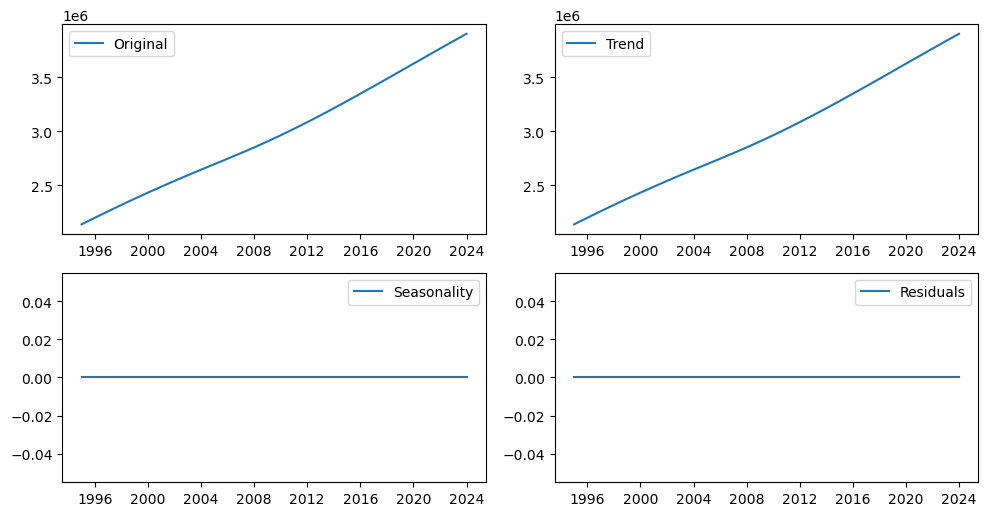



Qatar


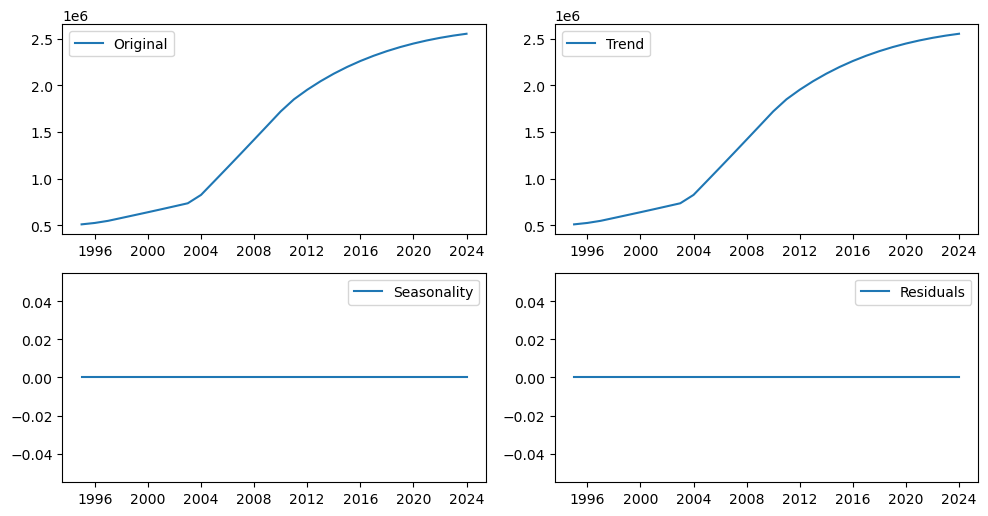



Saudi Arabia


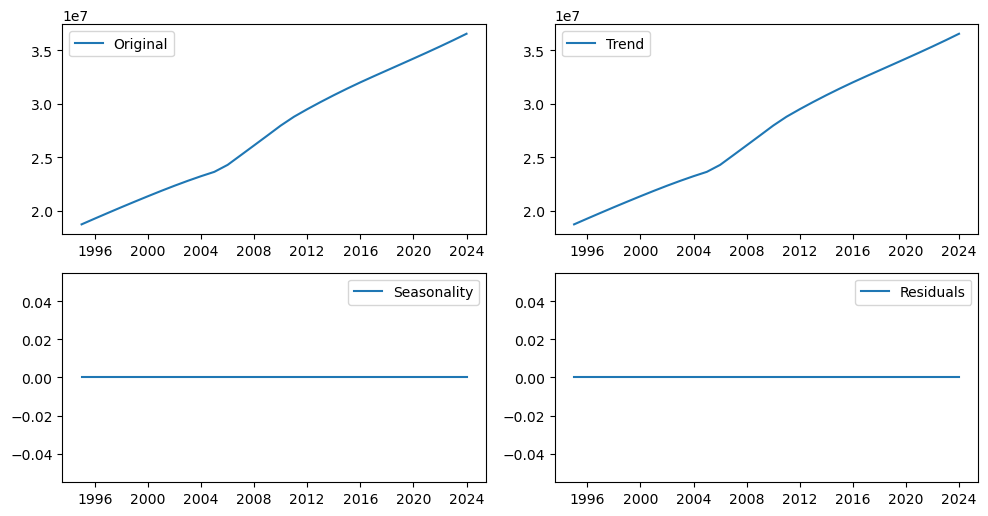



United Arab Emirates


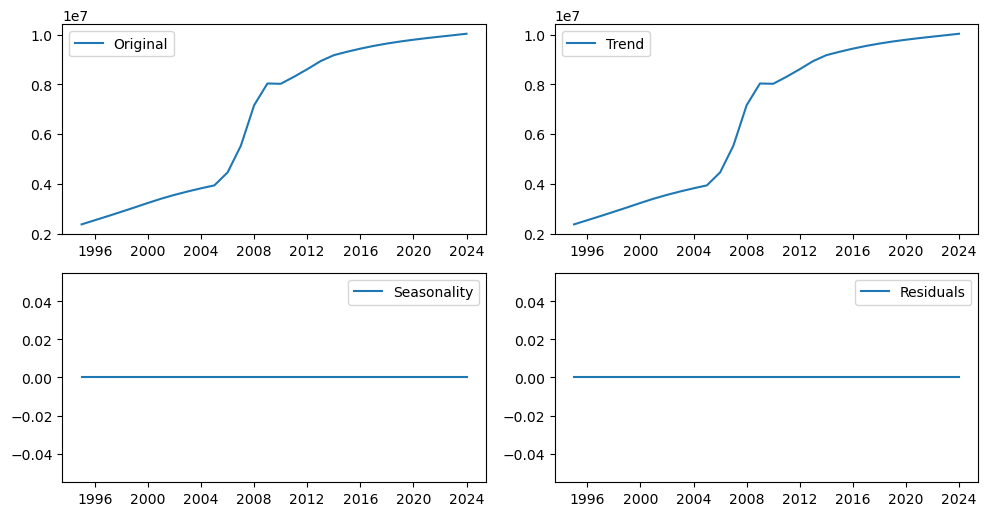

In [211]:
from statsmodels.tsa.seasonal import seasonal_decompose

for dataframe in dataframes:
    print(dataframe['Country'].values[0])
    # seasonal decompose each time series to see the trend seasonality and residual
    additive_decomposition = seasonal_decompose(dataframe['Population'], model='additive', period=1)
    
    # Take each component separately 
    trend = additive_decomposition.trend
    seasonal = additive_decomposition.seasonal
    residual = additive_decomposition.resid
    
    # Plot each component separately
    plt.figure(figsize=(10, 10))
    
    plt.subplot(421)
    plt.plot(dataframe['Population'], label='Original')
    plt.legend(loc='best')
    
    plt.subplot(422)
    plt.plot(trend, label='Trend')
    plt.legend(loc='best')
    
    plt.subplot(423)
    plt.plot(seasonal,label='Seasonality')
    plt.legend(loc='best')
    
    plt.subplot(424)
    plt.plot(residual, label='Residuals')
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()

    print('\n')

All the time series only have trend, no seasonality and no risiduals so use ARIMA model with trend differencing 

### ARIMA
Fits ARIMA models to each country's population data. The model uses parameter tuning and residual diagnostics. Forecasts are generated and evaluated using RMSE.

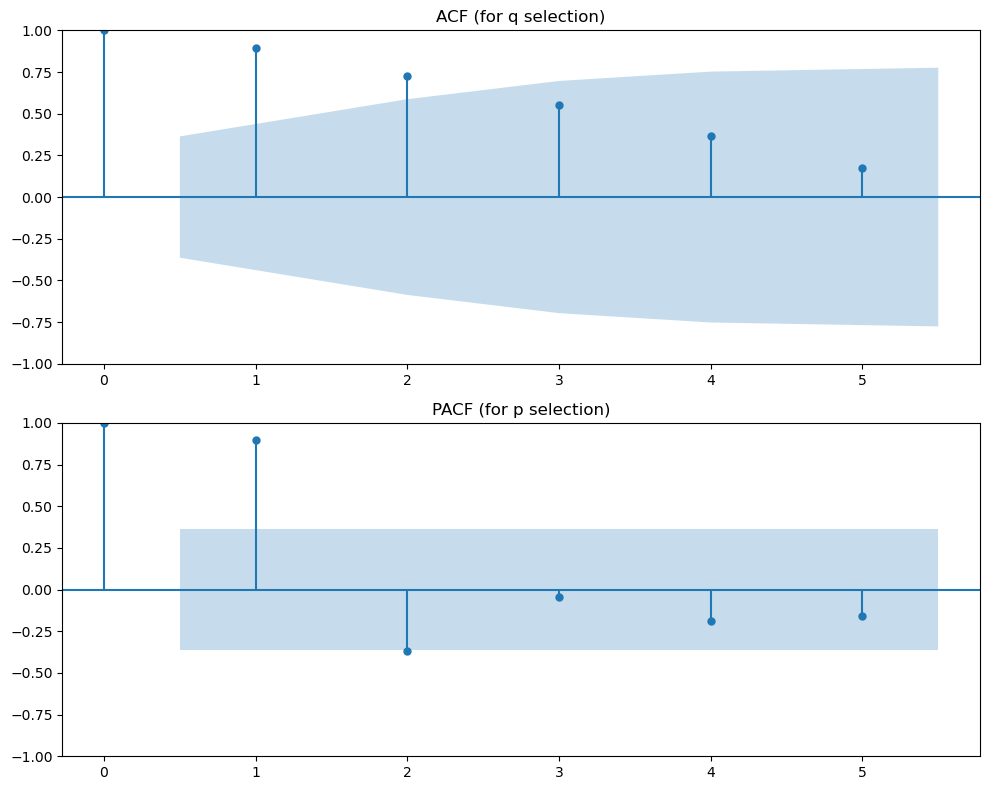

In [271]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

ts = df_qr['Population'] 
ts = ts.dropna()

ts_diff = ts.diff().dropna()

# Plot ACF and PACF
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(ts_diff, ax=ax[0], lags=5)
ax[0].set_title('ACF (for q selection)')

plot_pacf(ts_diff, ax=ax[1], lags=5, method='ywm')
ax[1].set_title('PACF (for p selection)')

plt.tight_layout()
plt.show()


/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_13136/1267405895.py:25: FutureWarning: 'Y' is deprecated and w

RMSE for Bahrain: 98901.9098479784
MAE for Bahrain: 96992.61
R² for Bahrain: -43.0971


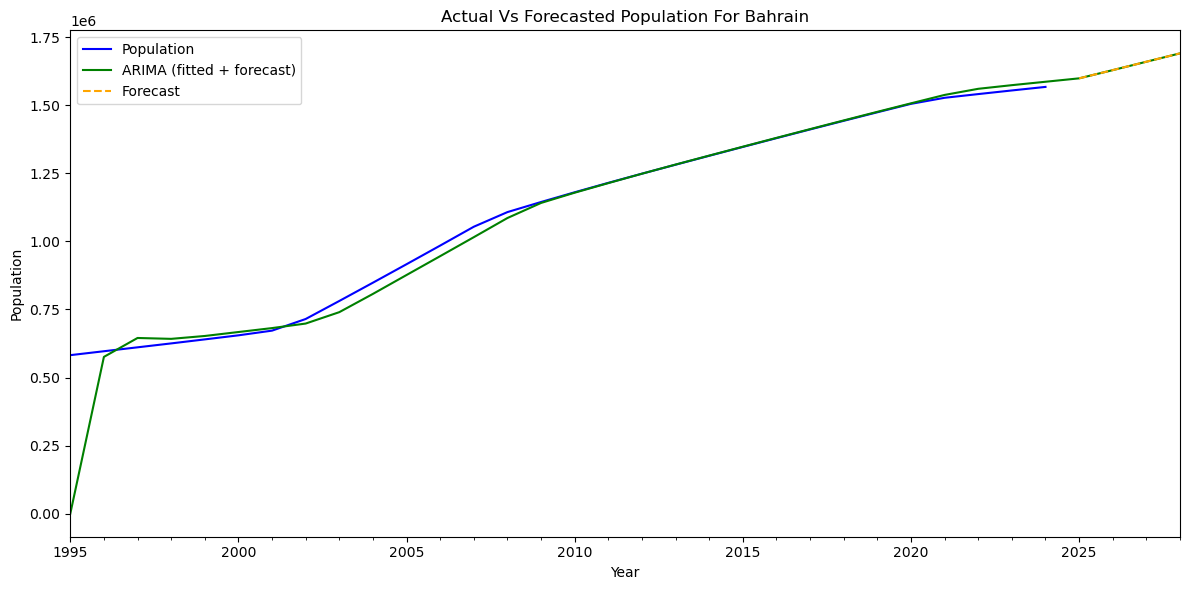

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmod

RMSE for Kuwait: 144109.47149398044
MAE for Kuwait: 144108.73
R² for Kuwait: -12.2347


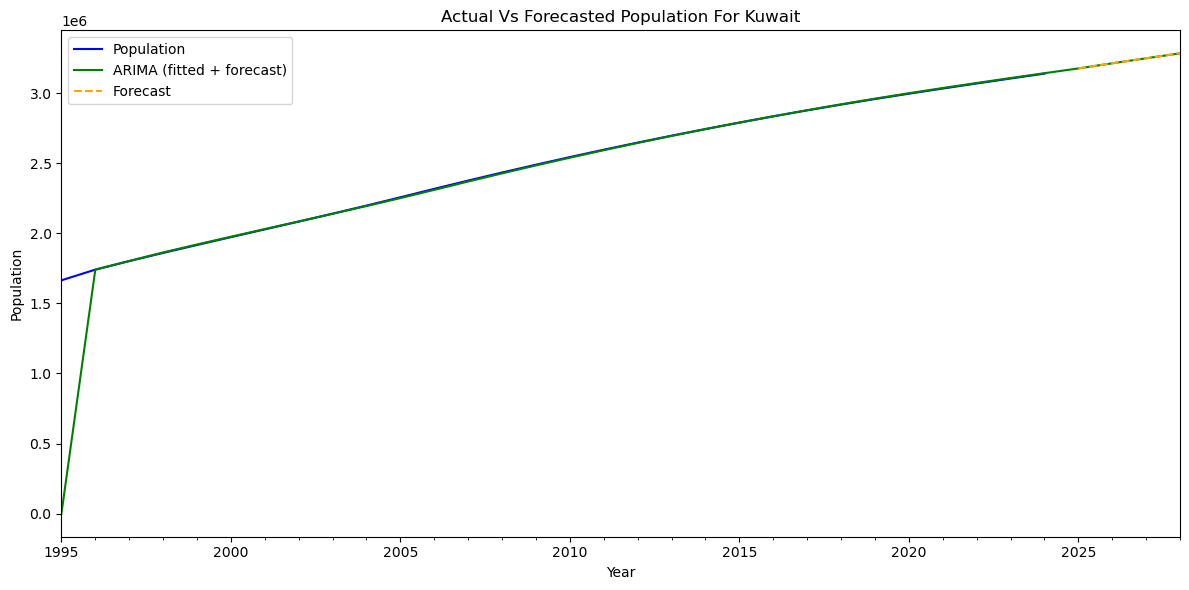

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-

RMSE for Oman: 254896.37344872704
MAE for Oman: 254716.96
R² for Oman: -9.8911


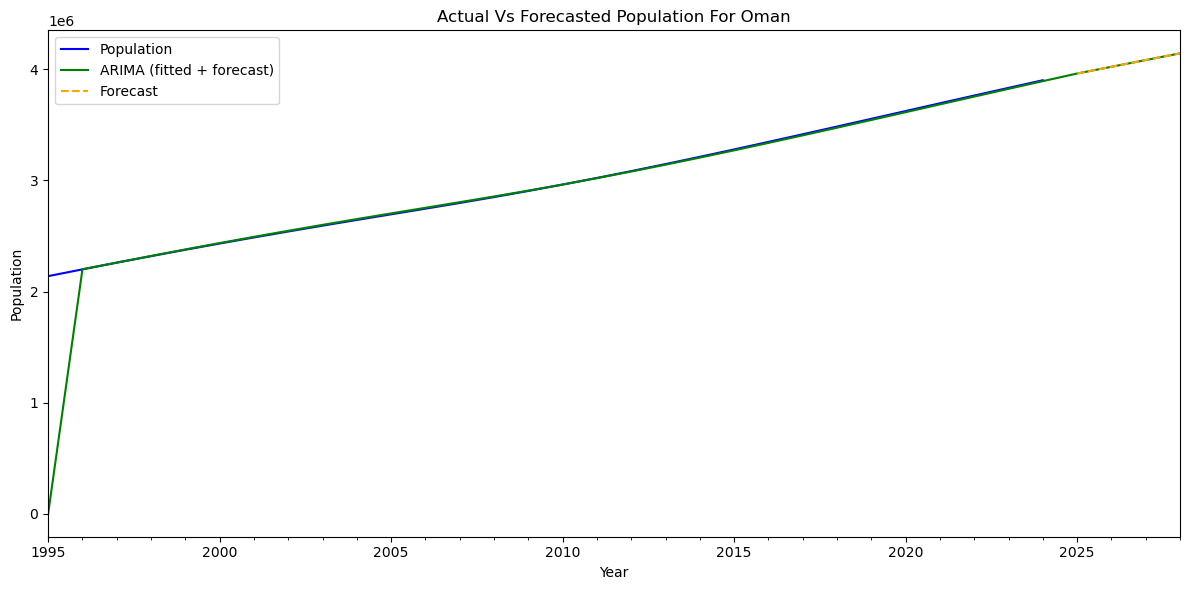

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmod

RMSE for Qatar: 194682.75681020165
MAE for Qatar: 189124.54
R² for Qatar: -51.248


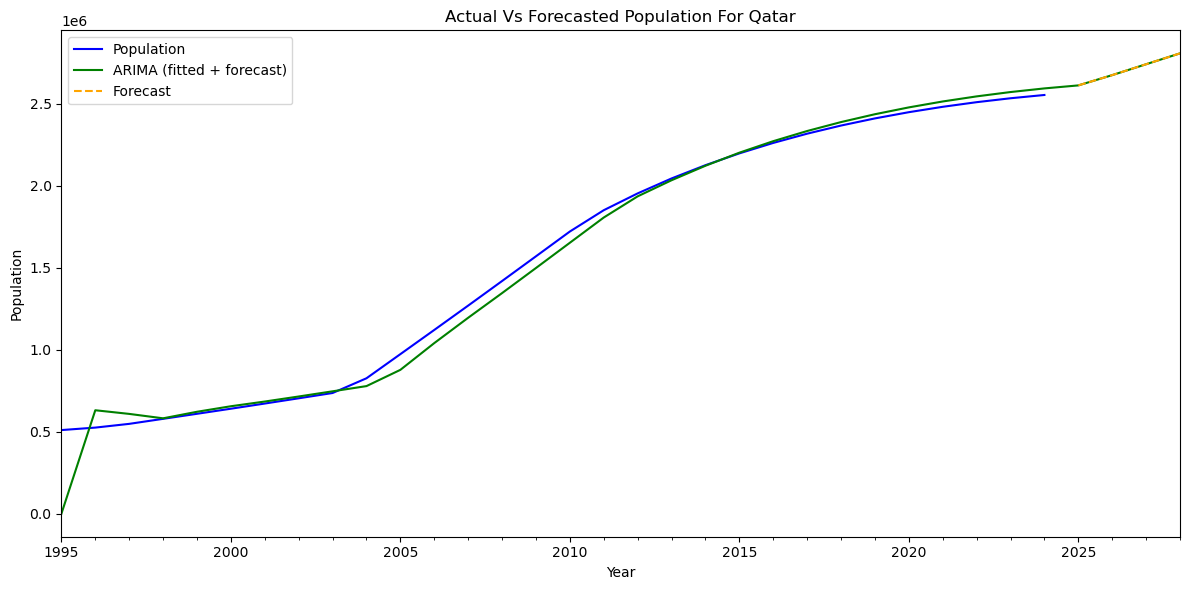

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_13136/1267405895.py:25: FutureWarning: 'Y' is deprecated and w

RMSE for Saudi Arabia: 4392668.141498721
MAE for Saudi Arabia: 4311475.45
R² for Saudi Arabia: -43.8307


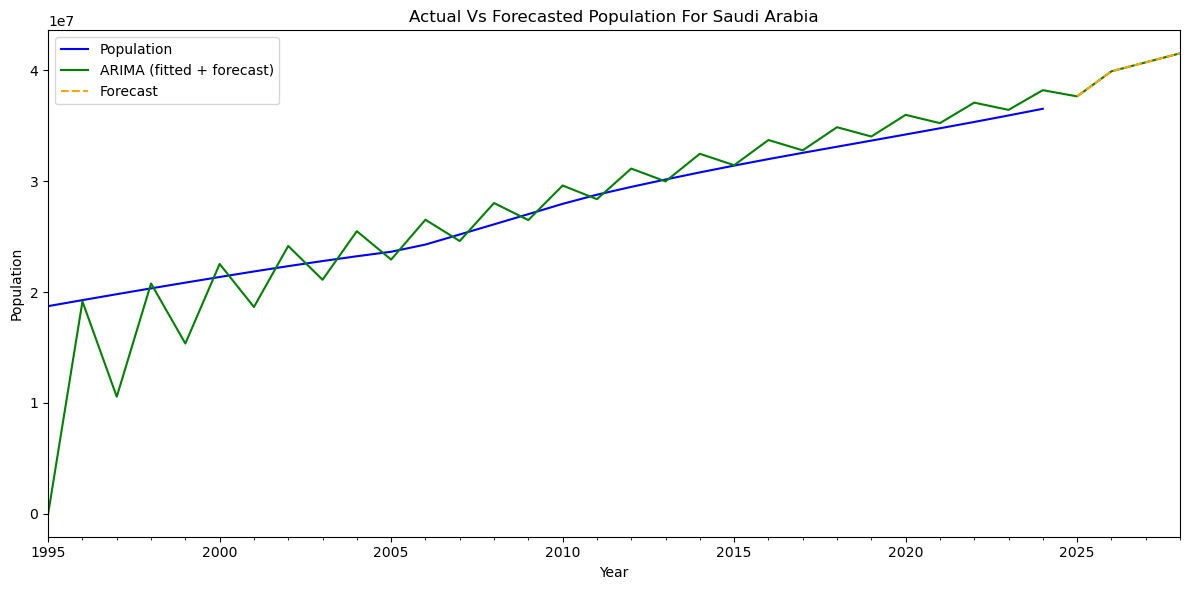

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_13136/1267405895.py:25: FutureWarning: 'Y' is deprecated and w

RMSE for United Arab Emirates: 646732.6455129394
MAE for United Arab Emirates: 617389.47
R² for United Arab Emirates: -96.9571


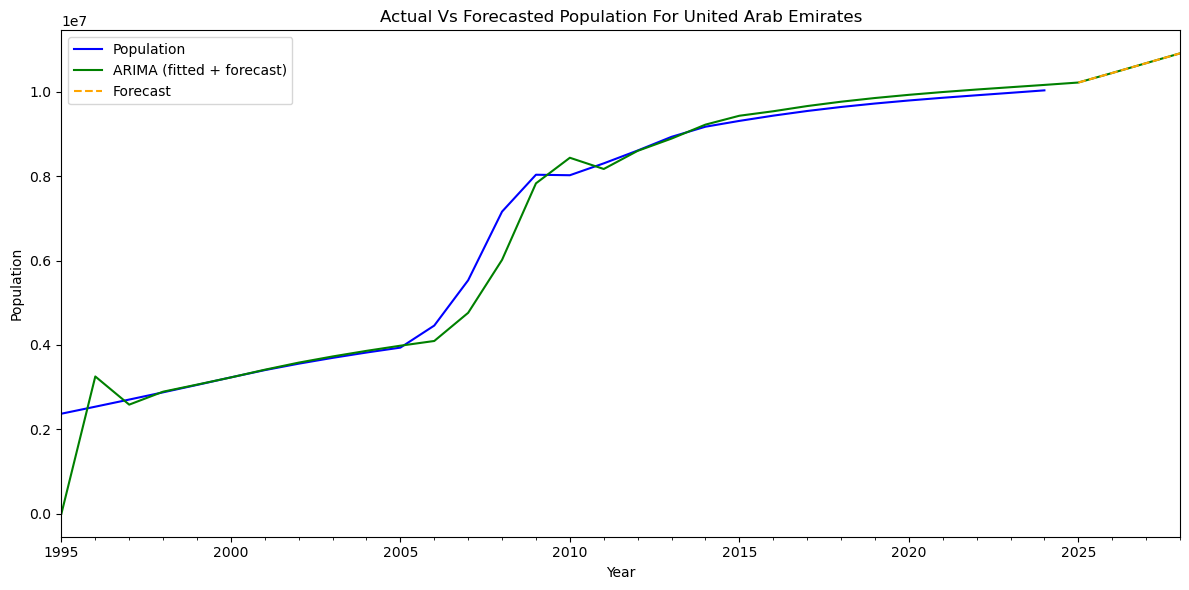

In [294]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# List to store forecast DataFrames
all_forecasts = []

def arima(y, y_to_train, y_to_test, predict_date, country, full_years):
    model = ARIMA(y, order=(1, 1, 3))
    fit1 = model.fit()
    fcast1 = fit1.forecast(predict_date).rename("ARIMA")
    rmse = np.sqrt(mean_squared_error(y_to_test.values, fcast1.values))
    mae = mean_absolute_error(y_to_test.values, fcast1.values)
    r2 = r2_score(y_to_test.values, fcast1.values)

    print(f'RMSE for {country}: {rmse}')
    print(f'MAE for {country}: {round(mae, 2)}')
    print(f'R² for {country}: {round(r2, 4)}')


    # Create forecast years
    start_year = full_years.max() + 1
    forecast_years = list(range(start_year, start_year + predict_date))
    
    start_year = full_years.max() + 1
    forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
    future_fcast = pd.Series(fit1.forecast(predict_date).values, index=forecast_years, name="ARIMA")

    forecast_df = pd.DataFrame({
        'Year': forecast_years,
        'Country': country,
        'Forecasted Population': future_fcast.values
    })
    all_forecasts.append(forecast_df)

    # plotting
    plt.figure(figsize=(10, 4))
    plt.title(f"Actual Vs Forecasted Population For {country}")
    
    y.plot(color='blue', label='Population')

    # Combine fitted values with forecast
    full_model = pd.concat([fit1.fittedvalues, future_fcast])
    full_model.plot(color='green', label="ARIMA (fitted + forecast)")
    
    # Highlight the forecast part (dashed overlay for visibility)
    future_fcast.plot(color='orange', linestyle='--', label='Forecast')

    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.xlim(pd.Timestamp('1995'), pd.Timestamp('2028'))
    plt.legend()
    plt.tight_layout()
    plt.show()

# Main loop over your list of DataFrames
for dataframe in dataframes:
    dataframe = dataframe.copy()
    dataframe.index = pd.to_datetime(dataframe.index)
    y = dataframe['Population']
    y_to_train = dataframe[dataframe['Year'] <= '2020-01-01']['Population']
    y_to_val = dataframe[dataframe['Year'] > '2020-01-01']['Population']
    country = dataframe['Country'].values[0]
    full_years = dataframe.index.year
    
    arima(y, y_to_train, y_to_val, 4, country, full_years)

# Combine and save all forecasts
final_forecast_df = pd.concat(all_forecasts, ignore_index=True)
final_forecast_df['Forecasted Population'] = final_forecast_df['Forecasted Population'].astype(int)
final_forecast_df.to_csv('arima_population_forecasts.csv', index=False)

### Holt's linear model
This model is specifically good for time series with trend but no seasonality.
Fits Holt’s Linear Trend model to population data, capturing trend. Visual comparisons with ARIMA are included.

RMSE for Bahrain: 48489.18097496544
MAE for Bahrain: 43050.64
R² for Bahrain: -9.5996


/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


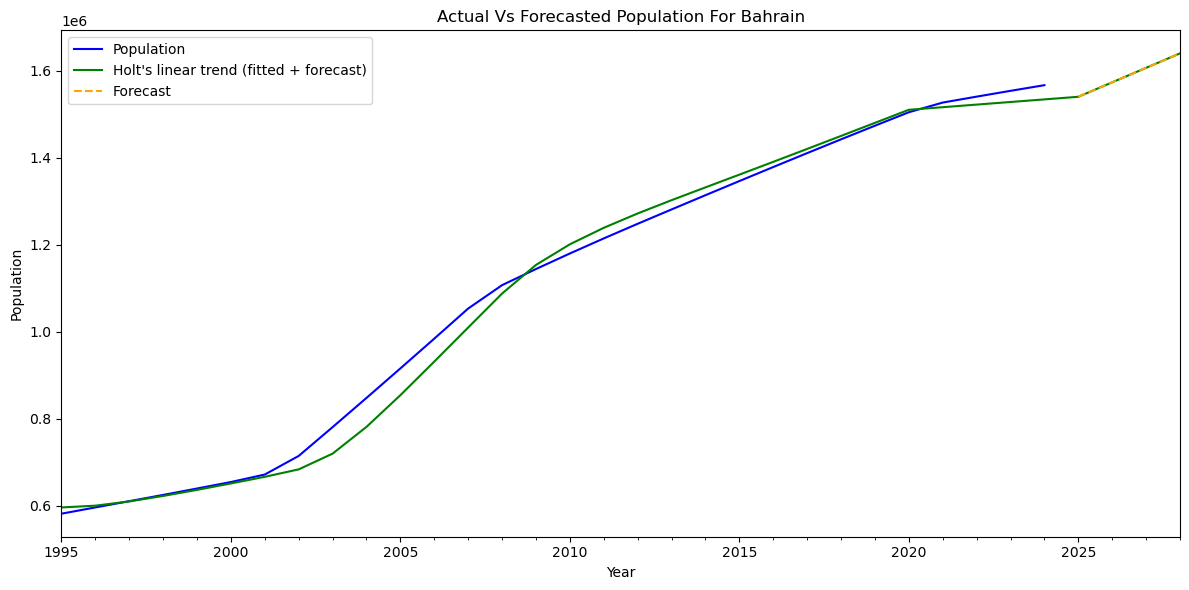

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


RMSE for Kuwait: 27351.30181240615
MAE for Kuwait: 25512.07
R² for Kuwait: 0.5233


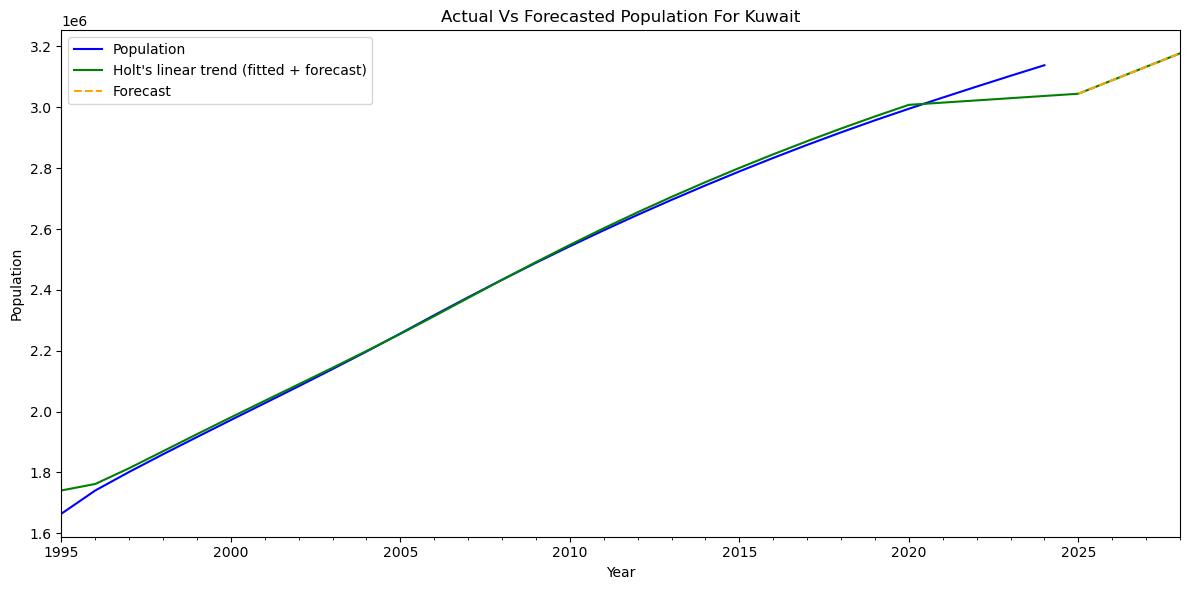

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


RMSE for Oman: 10796.297166358167
MAE for Oman: 10445.0
R² for Oman: 0.9805


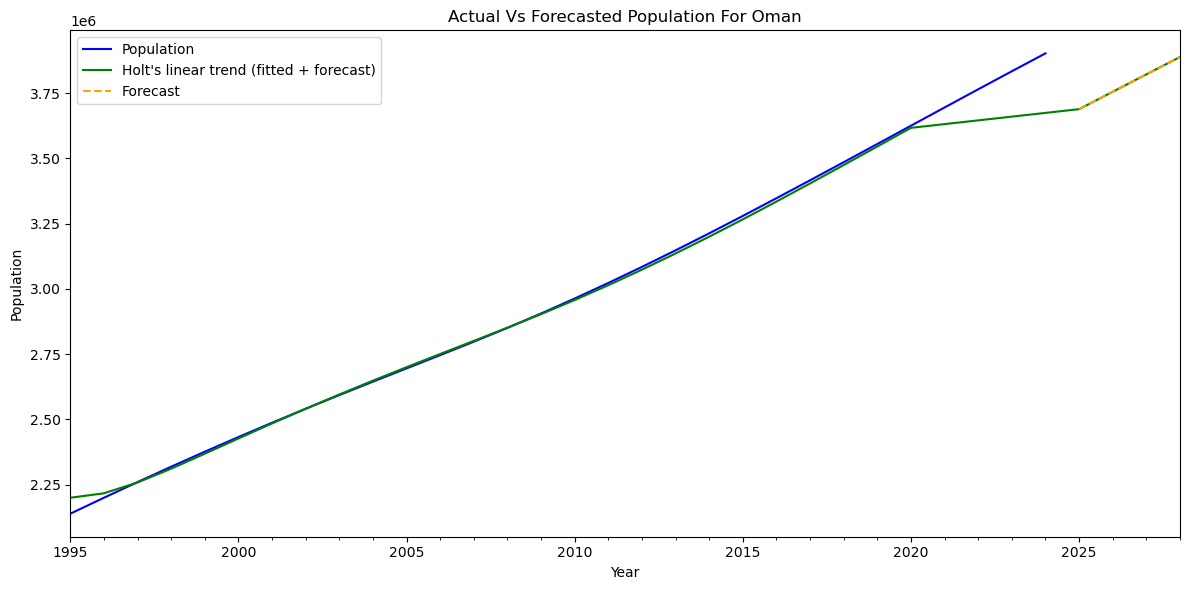

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


RMSE for Qatar: 129283.04956902537
MAE for Qatar: 120232.58
R² for Qatar: -22.0408


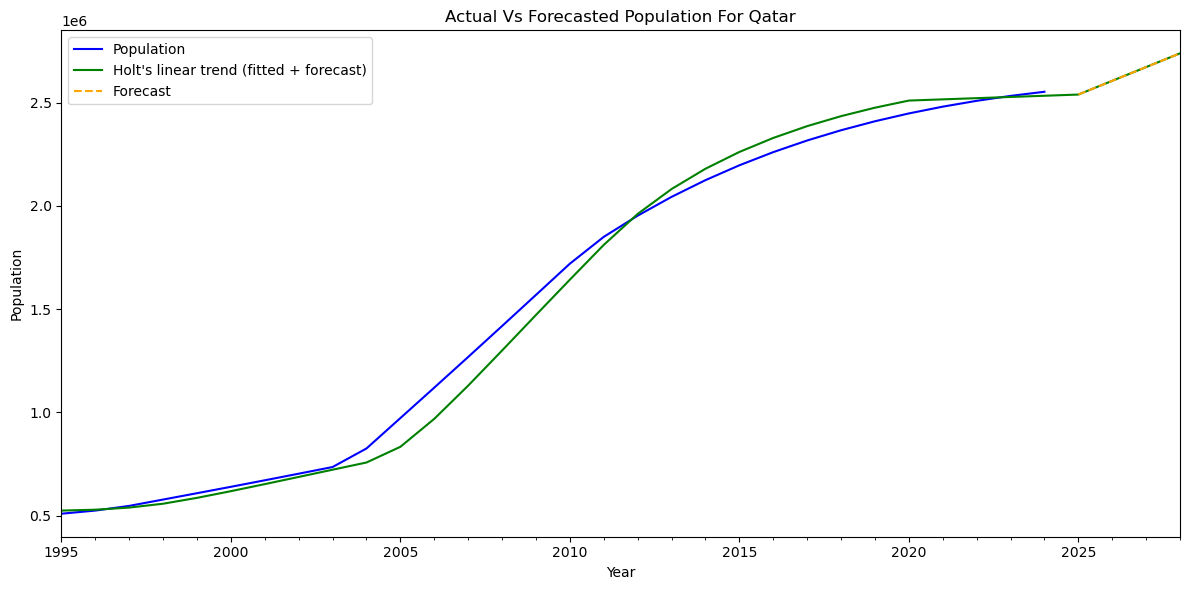

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


RMSE for Saudi Arabia: 143681.29390485454
MAE for Saudi Arabia: 141634.67
R² for Saudi Arabia: 0.952


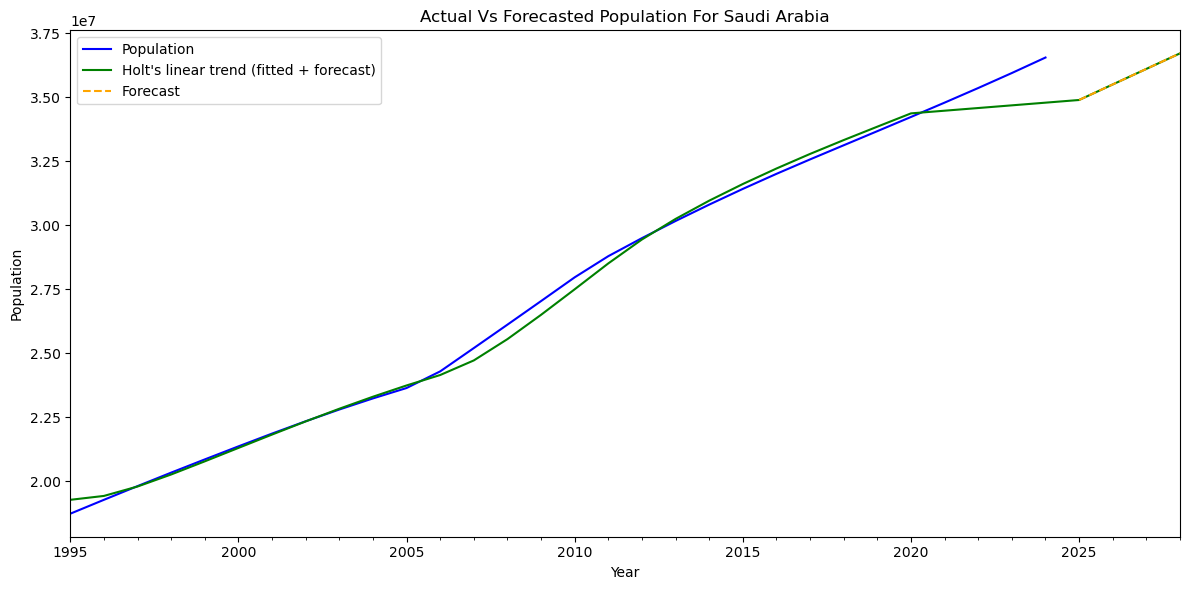

RMSE for United Arab Emirates: 396598.85173795966
MAE for United Arab Emirates: 375678.79
R² for United Arab Emirates: -35.8374


/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_13136/3659511722.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')


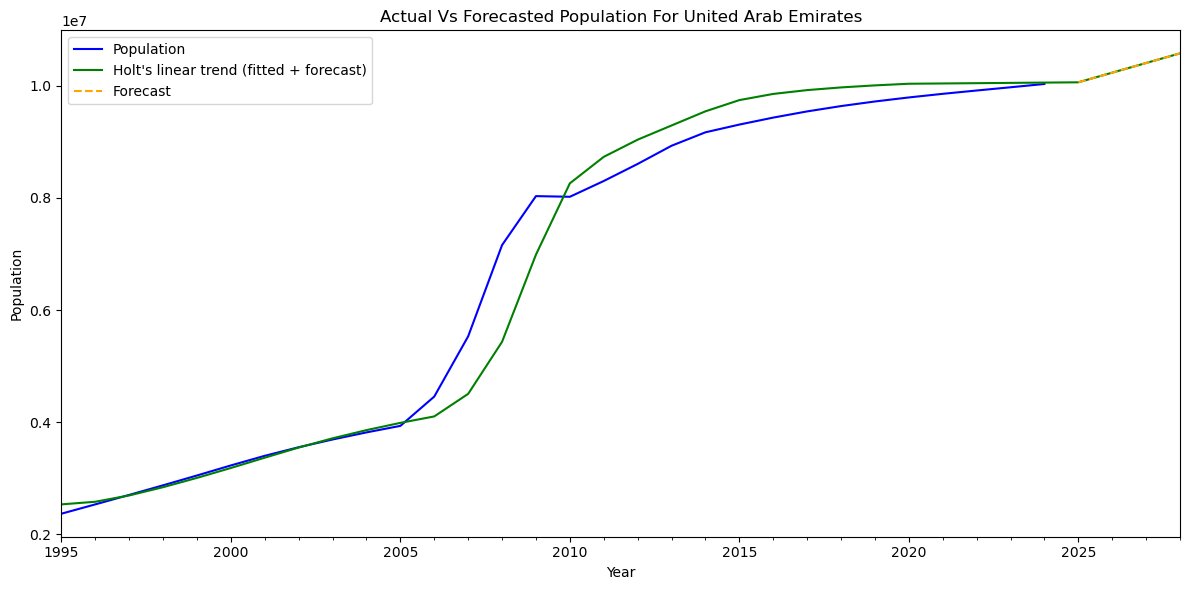

In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import Holt

# List to store forecast DataFrames
all_forecasts = []

def holt(y, y_to_train, y_to_test, smoothing_level, smoothing_slope, predict_date, country, full_years):
    fit1 = Holt(y_to_train).fit(smoothing_level, smoothing_slope, optimized=False)
    fcast1 = fit1.forecast(predict_date).rename("Holt's linear trend")
    
    rmse = np.sqrt(mean_squared_error(y_to_test.values, fcast1.values))
    mae = mean_absolute_error(y_to_test.values, fcast1.values)
    r2 = r2_score(y_to_test.values, fcast1.values)

    print(f'RMSE for {country}: {rmse}')
    print(f'MAE for {country}: {round(mae, 2)}')
    print(f'R² for {country}: {round(r2, 4)}')

    # Create forecast years
    start_year = full_years.max() + 1
    forecast_years = list(range(start_year, start_year + predict_date))
    
    start_year = full_years.max() + 1
    forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
    future_fcast = pd.Series(fit1.forecast(predict_date).values, index=forecast_years, name="Holt's linear trend")

    forecast_df = pd.DataFrame({
        'Year': forecast_years,
        'Country': country,
        'Forecasted Population': future_fcast.values
    })
    all_forecasts.append(forecast_df)

    # plotting
    plt.figure(figsize=(12, 6))
    plt.title(f"Actual Vs Forecasted Population For {country}")
    
    y.plot(color='blue', label='Population')
    fit1.fittedvalues.plot(color='green')
    fcast1.plot(color='green', legend=True)
    future_fcast.plot(color='orange', linestyle='--', label='Forecast')

    # Combine fitted values with forecast
    full_model = pd.concat([fit1.fittedvalues, future_fcast])
    full_model.plot(color='green', label="Holt's linear trend (fitted + forecast)")
    
    # Highlight the forecast part (dashed overlay for visibility)
    future_fcast.plot(color='orange', linestyle='--', label='Forecast')

    plt.xlabel('Year')
    plt.ylabel('Population')
    plt.xlim(pd.Timestamp('1995'), pd.Timestamp('2028'))
    plt.legend()
    plt.tight_layout()
    plt.show()

# Main loop over your list of DataFrames
for dataframe in dataframes:
    dataframe = dataframe.copy()
    dataframe.index = pd.to_datetime(dataframe.index)

    y = dataframe['Population']
    y_to_train = dataframe[dataframe['Year'] <= '2020-01-01']['Population']
    y_to_val = dataframe[dataframe['Year'] > '2020-01-01']['Population']
    country = dataframe['Country'].values[0]
    full_years = dataframe.index.year
    
    holt(y, y_to_train, y_to_val, 0.6, 0.2, 4, country, full_years)

# Combine and save all forecasts
final_forecast_df = pd.concat(all_forecasts, ignore_index=True)
final_forecast_df['Forecasted Population'] = final_forecast_df['Forecasted Population'].astype(int)
final_forecast_df.to_csv('holt_population_forecasts.csv', index=False)

### Exporting the data
Exports the ARIMA-based forecast data to CSV for use in Power BI or future analysis.

In [337]:
arima_forecast = pd.read_csv('arima_population_forecasts.csv')

arima_forecast.head()

,Year,Country,Forecasted Population
0,2025-12-31,Bahrain,1598306
1,2026-12-31,Bahrain,1628508
2,2027-12-31,Bahrain,1659328
3,2028-12-31,Bahrain,1690087
4,2025-12-31,Kuwait,3175543


In [338]:
arima_forecast.dtypes

Year                     object
Country                  object
Forecasted Population     int64
dtype: object

In [339]:
# Ensure 'Year' is datetime
arima_forecast['Year'] = pd.to_datetime(arima_forecast['Year'])

# Replace the date to January 1st of the same year
arima_forecast['Year'] = arima_forecast['Year'].apply(lambda x: x.replace(month=1, day=1))

# Optional: check result
print(arima_forecast['Year'].head())


0   2025-01-01
1   2026-01-01
2   2027-01-01
3   2028-01-01
4   2025-01-01
Name: Year, dtype: datetime64[ns]


In [340]:
arima_forecast.dtypes

Year                     datetime64[ns]
Country                          object
Forecasted Population             int64
dtype: object

In [341]:
arima_forecast.rename(columns = {'Forecasted Population': 'Population'}, inplace = True)
arima_forecast.head()

,Year,Country,Population
0,2025-01-01,Bahrain,1598306
1,2026-01-01,Bahrain,1628508
2,2027-01-01,Bahrain,1659328
3,2028-01-01,Bahrain,1690087
4,2025-01-01,Kuwait,3175543


In [345]:
arima_forecast.to_csv('arima_population_forecasts.csv')

### More predictions
Extends forecasts to gender based predictions with ARIMA for future population planning.

In [11]:
df_f = df[['Year', 'Country', 'Female Population']]
df_m = df[['Year', 'Country', 'Male Population']]
# set year as index
df_f.set_index('Year', inplace=True)
df_m.set_index('Year', inplace=True)
df_f['Year'] = df_f.index
df_m['Year'] = df_m.index

/tmp/ipykernel_488/664987470.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['Year'] = df_f.index
/tmp/ipykernel_488/664987470.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_m['Year'] = df_m.index


In [12]:
df_m.head()

,Country,Male Population,Year
Year,,,
1995-01-01,Bahrain,333212.0,1995-01-01
1995-01-01,Kuwait,961411.0,1995-01-01
1995-01-01,Oman,1239069.0,1995-01-01
1995-01-01,Qatar,333717.0,1995-01-01
1995-01-01,Saudi Arabia,10589875.0,1995-01-01


In [13]:
# create new dataframes for each coutry 
countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']
dataframes = {}

for country in countries:
    temp = df_f[df_f['Country'] == country]
    dataframes[country] = temp

df_bh = dataframes['Bahrain']
df_kw = dataframes['Kuwait']
df_om = dataframes['Oman']
df_qr = dataframes['Qatar']
df_sa = dataframes['Saudi Arabia']
df_uae = dataframes['United Arab Emirates']

In [14]:
dataframes = [df_bh, df_kw, df_om, df_qr, df_sa, df_uae]

In [16]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# List to store forecast DataFrames
all_forecasts = []

def arima(y, y_to_train, y_to_test, predict_date, country, full_years):
    model = ARIMA(y, order=(1, 1, 3))
    fit1 = model.fit()
    fcast1 = fit1.forecast(predict_date).rename("ARIMA")
    rmse = np.sqrt(mean_squared_error(y_to_test.values, fcast1.values))
    mae = mean_absolute_error(y_to_test.values, fcast1.values)
    r2 = r2_score(y_to_test.values, fcast1.values)

    print(f'RMSE for {country}: {rmse}')
    print(f'MAE for {country}: {round(mae, 2)}')
    print(f'R² for {country}: {round(r2, 4)}')


    # Create forecast years
    start_year = full_years.max() + 1
    forecast_years = list(range(start_year, start_year + predict_date))
    
    start_year = full_years.max() + 1
    forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
    future_fcast = pd.Series(fit1.forecast(predict_date).values, index=forecast_years, name="ARIMA")

    forecast_df = pd.DataFrame({
        'Year': forecast_years,
        'Country': country,
        'Forecasted Population': future_fcast.values
    })
    all_forecasts.append(forecast_df)

# Main loop over your list of DataFrames
for dataframe in dataframes:
    dataframe = dataframe.copy()
    dataframe.index = pd.to_datetime(dataframe.index)
    y = dataframe['Female Population']
    y_to_train = dataframe[dataframe['Year'] <= '2020-01-01']['Female Population']
    y_to_val = dataframe[dataframe['Year'] > '2020-01-01']['Female Population']
    country = dataframe['Country'].values[0]
    full_years = dataframe.index.year
    
    arima(y, y_to_train, y_to_val, 4, country, full_years)

# Combine and save all forecasts
final_forecast_df = pd.concat(all_forecasts, ignore_index=True)
final_forecast_df['Forecasted Population'] = final_forecast_df['Forecasted Population'].astype(int)
final_forecast_df.to_csv('female_population_forecasts.csv', index=False)

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_488/3773364965.py:26: FutureWarning: 'Y' is deprecated and wil

RMSE for Bahrain: 41116.71373857299
MAE for Bahrain: 40886.68
R² for Bahrain: -22.0224
RMSE for Kuwait: 80329.39529690213
MAE for Kuwait: 80229.1
R² for Kuwait: -15.21
RMSE for Oman: 129712.16450902543
MAE for Oman: 129654.08
R² for Oman: -10.2374
RMSE for Qatar: 46160.91989419906
MAE for Qatar: 45711.79
R² for Qatar: -25.3324
RMSE for Saudi Arabia: 495155.4758767989
MAE for Saudi Arabia: 461648.14
R² for Saudi Arabia: -2.2148
RMSE for United Arab Emirates: 292312.4496319994
MAE for United Arab Emirates: 291217.13
R² for United Arab Emirates: -18.3813


/tmp/ipykernel_488/3773364965.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_488/3773364965.py:26: FutureWarning: 'Y' is deprecated and will be removed in a 

In [17]:
# create new dataframes for each coutry 
countries = ['Bahrain', 'Kuwait', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']
dataframes = {}

for country in countries:
    temp = df_m[df_m['Country'] == country]
    dataframes[country] = temp

df_bh = dataframes['Bahrain']
df_kw = dataframes['Kuwait']
df_om = dataframes['Oman']
df_qr = dataframes['Qatar']
df_sa = dataframes['Saudi Arabia']
df_uae = dataframes['United Arab Emirates']

In [19]:
dataframes = [df_bh, df_kw, df_om, df_qr, df_sa, df_uae]

In [20]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# List to store forecast DataFrames
all_forecasts = []

def arima(y, y_to_train, y_to_test, predict_date, country, full_years):
    model = ARIMA(y, order=(1, 1, 3))
    fit1 = model.fit()
    fcast1 = fit1.forecast(predict_date).rename("ARIMA")
    rmse = np.sqrt(mean_squared_error(y_to_test.values, fcast1.values))
    mae = mean_absolute_error(y_to_test.values, fcast1.values)
    r2 = r2_score(y_to_test.values, fcast1.values)

    print(f'RMSE for {country}: {rmse}')
    print(f'MAE for {country}: {round(mae, 2)}')
    print(f'R² for {country}: {round(r2, 4)}')


    # Create forecast years
    start_year = full_years.max() + 1
    forecast_years = list(range(start_year, start_year + predict_date))
    
    start_year = full_years.max() + 1
    forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
    future_fcast = pd.Series(fit1.forecast(predict_date).values, index=forecast_years, name="ARIMA")

    forecast_df = pd.DataFrame({
        'Year': forecast_years,
        'Country': country,
        'Forecasted Population': future_fcast.values
    })
    all_forecasts.append(forecast_df)

# Main loop over your list of DataFrames
for dataframe in dataframes:
    dataframe = dataframe.copy()
    dataframe.index = pd.to_datetime(dataframe.index)
    y = dataframe['Male Population']
    y_to_train = dataframe[dataframe['Year'] <= '2020-01-01']['Male Population']
    y_to_val = dataframe[dataframe['Year'] > '2020-01-01']['Male Population']
    country = dataframe['Country'].values[0]
    full_years = dataframe.index.year
    
    arima(y, y_to_train, y_to_val, 4, country, full_years)

# Combine and save all forecasts
final_forecast_df = pd.concat(all_forecasts, ignore_index=True)
final_forecast_df['Forecasted Population'] = final_forecast_df['Forecasted Population'].astype(int)
final_forecast_df.to_csv('male_population_forecasts.csv', index=False)

/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_488/3126522298.py:26: FutureWarning: 'Y' is deprecated and wil

RMSE for Bahrain: 61858.48707394666
MAE for Bahrain: 59582.18
R² for Bahrain: -94.6638
RMSE for Kuwait: 70307.2699692597
MAE for Kuwait: 70306.41
R² for Kuwait: -11.7875
RMSE for Oman: 125322.73530488873
MAE for Oman: 125194.73
R² for Oman: -9.5723


/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_488/3126522298.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
/home/jihane/an

RMSE for Qatar: 142328.57933065417
MAE for Qatar: 137091.53
R² for Qatar: -61.8711
RMSE for Saudi Arabia: 1541082.425978993
MAE for Saudi Arabia: 1525157.31
R² for Saudi Arabia: -15.4559
RMSE for United Arab Emirates: 235427.5431512313
MAE for United Arab Emirates: 209270.83
R² for United Arab Emirates: -15343.6377


/tmp/ipykernel_488/3126522298.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  forecast_years = pd.date_range(start=f'{start_year}', periods=predict_date, freq='Y')
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/home/jihane/anaconda3/envs/ml/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_488/3126522298.py:26: FutureWarning: 'Y' is deprecated and will be removed in a 

In [21]:
f_forecast = pd.read_csv('female_population_forecasts.csv')
f_forecast['Year'] = pd.to_datetime(f_forecast['Year'])
f_forecast['Year'] = f_forecast['Year'].apply(lambda x: x.replace(month=1, day=1))
f_forecast.rename(columns = {'Forecasted Population': 'Female Population'}, inplace = True)
f_forecast.to_csv('female_population_forecasts.csv')

In [22]:
m_forecast = pd.read_csv('male_population_forecasts.csv')
m_forecast['Year'] = pd.to_datetime(m_forecast['Year'])
m_forecast['Year'] = m_forecast['Year'].apply(lambda x: x.replace(month=1, day=1))
m_forecast.rename(columns = {'Forecasted Population': 'Male Population'}, inplace = True)
m_forecast.to_csv('male_population_forecasts.csv')